In [28]:
import pandas as pd

df = pd.read_csv('house_price.csv')
df.head()

,id,location,area_sqft,price,price_per_sqft,bedrooms,bathrooms
0,1,Kozhikkode,1200,15000000,12500,3,3
1,2,Wayanad,900,8000000,8889,2,2
2,3,Malappuram,1500,12500000,8333,3,3
3,4,Eranamkulam,800,4000000,5000,2,2
4,5,Palakkad,2000,30000000,15000,4,4


# Basic **EDA**

In [29]:
# Basic Info
df.info()

# Summary Stats
df.describe()

# Check Missing Values
print("\nMissing values:\n", df.isnull().sum())

# Column Names
print("\nColumns:", df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              20 non-null     int64 
 1   location        20 non-null     object
 2   area_sqft       20 non-null     int64 
 3   price           20 non-null     int64 
 4   price_per_sqft  20 non-null     int64 
 5   bedrooms        20 non-null     int64 
 6   bathrooms       20 non-null     int64 
dtypes: int64(6), object(1)
memory usage: 1.2+ KB

Missing values:
 id                0
location          0
area_sqft         0
price             0
price_per_sqft    0
bedrooms          0
bathrooms         0
dtype: int64

Columns: ['id', 'location', 'area_sqft', 'price', 'price_per_sqft', 'bedrooms', 'bathrooms']


# **Detect and Remove Outliers**

In [35]:
#Mean and Standard Deviation
mean = df['price_per_sqft'].mean()
std = df['price_per_sqft'].std()
df_mean_std = df[(df['price_per_sqft'] >= mean - 3*std) & (df['price_per_sqft'] <= mean + 3*std)]

In [36]:
#Percentile Method

lower_percentile = df['price_per_sqft'].quantile(0.01)
upper_percentile = df['price_per_sqft'].quantile(0.99)

df_percentile = df[(df['price_per_sqft'] >= lower_percentile) & (df['price_per_sqft'] <= upper_percentile)]

In [37]:
#IQR Method
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

df_iqr = df[(df['price_per_sqft'] >= Q1 - 1.5*IQR) & (df['price_per_sqft'] <= Q3 + 1.5*IQR)]

In [38]:
#Z-score Method
z_scores = np.abs(stats.zscore(df['price_per_sqft']))
df_zscore = df[(z_scores < 3)]

# **Boxplot for Comparison**

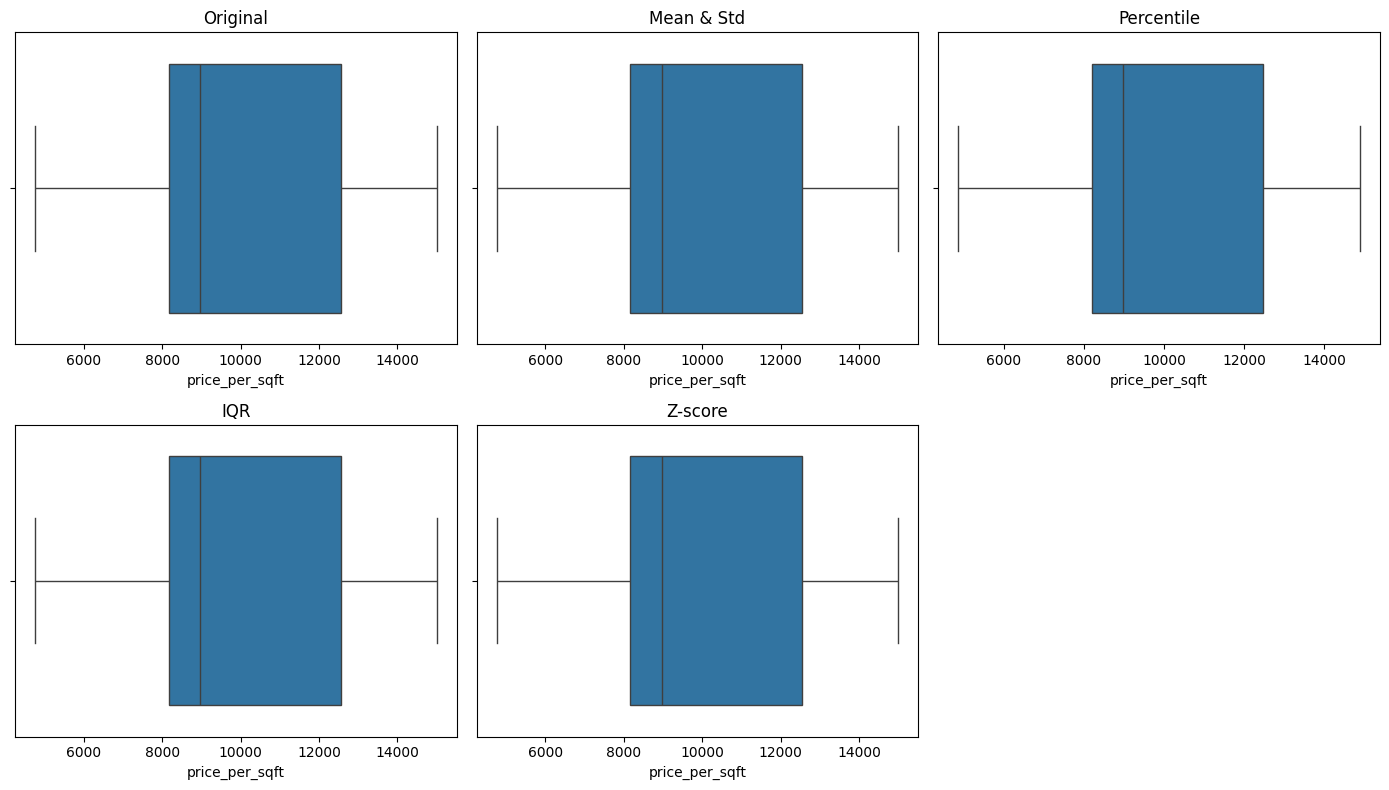

In [39]:
plt.figure(figsize=(14, 8))

plt.subplot(2, 3, 1)
sns.boxplot(x=df['price_per_sqft'])
plt.title('Original')

plt.subplot(2, 3, 2)
sns.boxplot(x=df_mean_std['price_per_sqft'])
plt.title('Mean & Std')

plt.subplot(2, 3, 3)
sns.boxplot(x=df_percentile['price_per_sqft'])
plt.title('Percentile')

plt.subplot(2, 3, 4)
sns.boxplot(x=df_iqr['price_per_sqft'])
plt.title('IQR')

plt.subplot(2, 3, 5)
sns.boxplot(x=df_zscore['price_per_sqft'])
plt.title('Z-score')

plt.tight_layout()
plt.show()

# **Histogram, Skewness & Transformation**

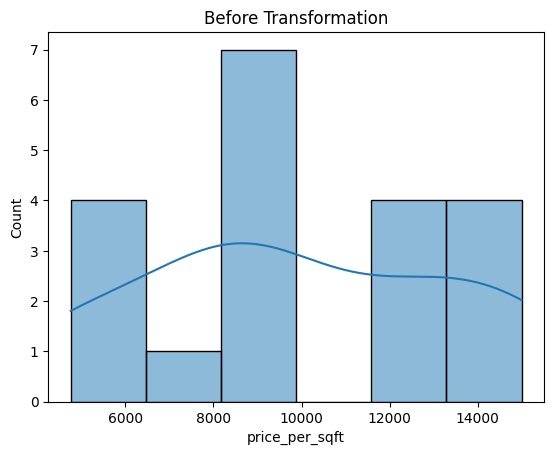

Skewness Before: 0.038490213660511655
Kurtosis Before: -1.2027233421968506


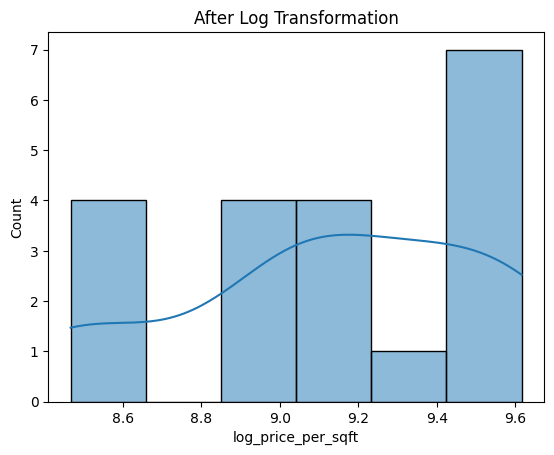

Skewness After: -0.4478407790002661
Kurtosis After: -0.9281909036385998


In [40]:
# Histplot Before
sns.histplot(df['price_per_sqft'], kde=True)
plt.title("Before Transformation")
plt.show()

# Skewness & Kurtosis
print("Skewness Before:", skew(df['price_per_sqft']))
print("Kurtosis Before:", kurtosis(df['price_per_sqft']))

# Log Transform
df['log_price_per_sqft'] = np.log1p(df['price_per_sqft'])

# Histplot After
sns.histplot(df['log_price_per_sqft'], kde=True)
plt.title("After Log Transformation")
plt.show()

# After Skewness & Kurtosis
print("Skewness After:", skew(df['log_price_per_sqft']))
print("Kurtosis After:", kurtosis(df['log_price_per_sqft']))

# **Correlation & Heatmap**

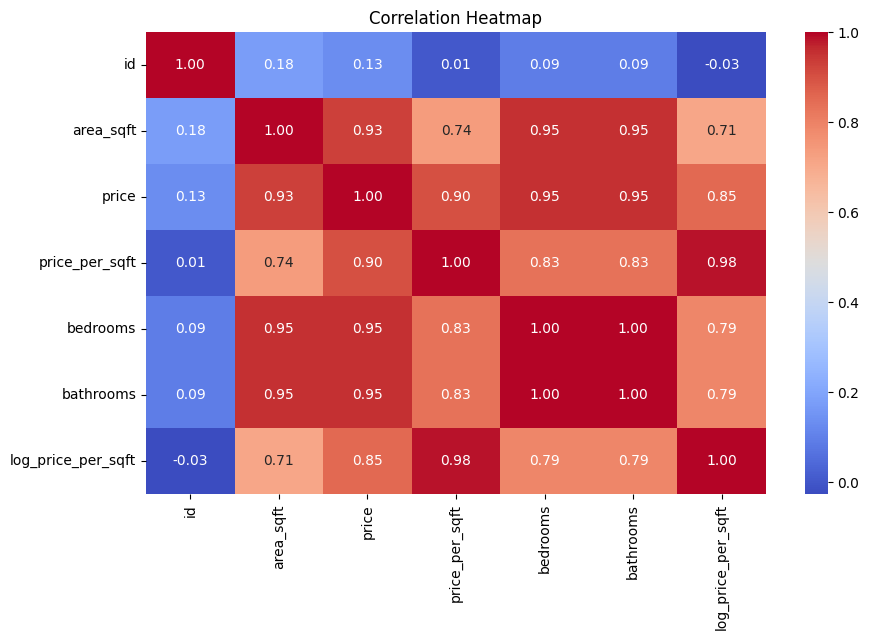

In [41]:
plt.figure(figsize=(10, 6))
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# **Scatter Plots Between Variables**

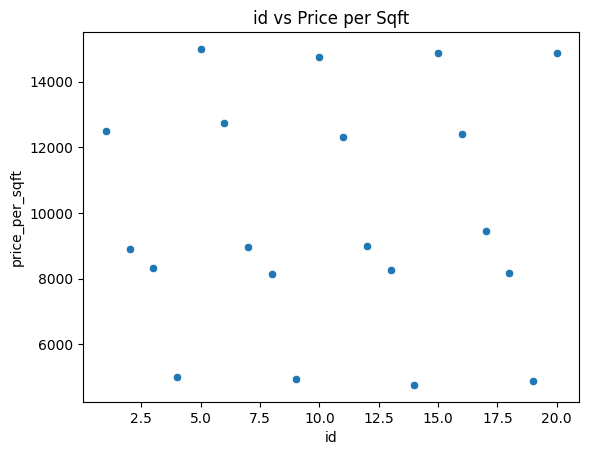

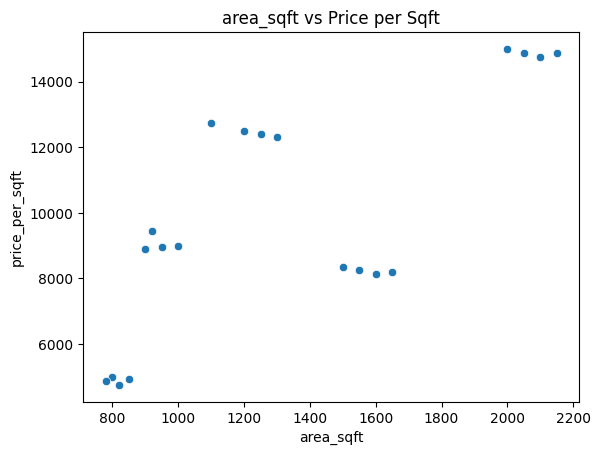

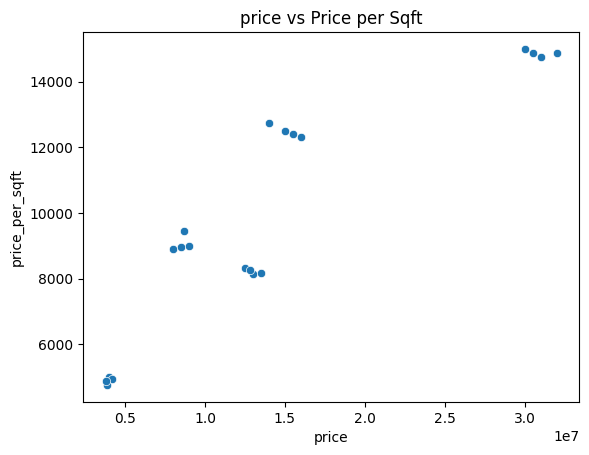

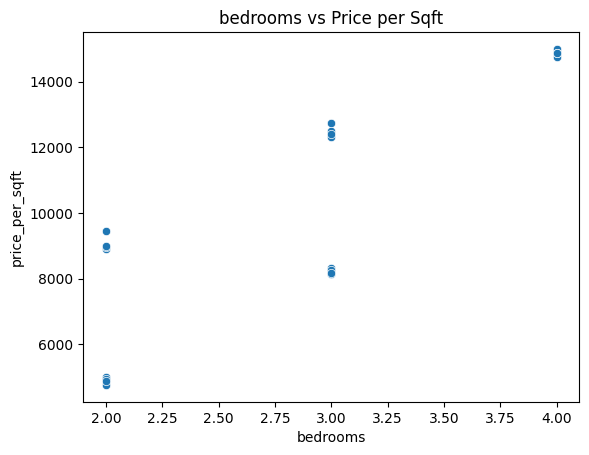

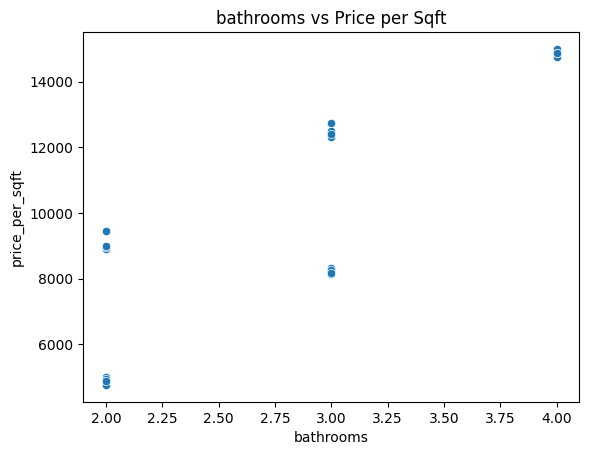

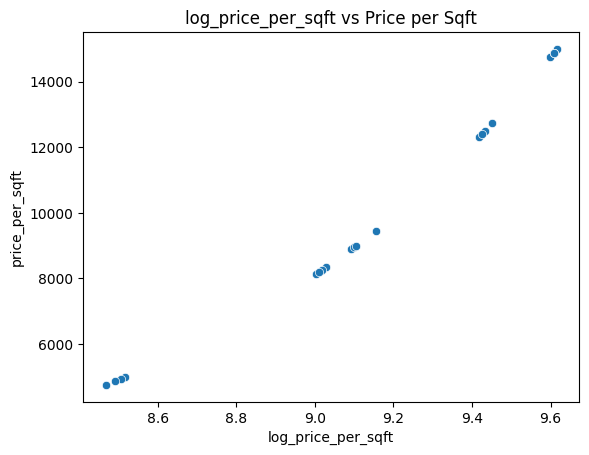

In [42]:
# Get all numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Scatter Plots
for col in numeric_cols:
    if col != 'price_per_sqft':
        sns.scatterplot(data=df, x=col, y='price_per_sqft')
        plt.title(f'{col} vs Price per Sqft')
        plt.show()